In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

# Load dataset
df = pd.read_csv("../data/synthetic/orders_data.csv")

df.head()

,order_id,city,category,customer_type,order_time,distance_km,order_value,delivery_fee,rider_cost,dark_store_cost,discount,delivery_time,gross_margin,contribution_margin,peak_hour
0,1,Chennai,Groceries,Discount-Seeker,2025-03-23 04:18:00,0.78,556.59,33.44,36.64,38.53,61.42,13.06,93.744181,-9.41,0
1,2,Pune,Groceries,Premium,2025-06-05 06:02:00,5.08,589.88,21.22,63.54,23.04,56.31,27.63,125.453680,3.78,0
2,3,Mumbai,Groceries,Premium,2025-02-26 02:07:00,4.55,574.73,21.45,63.81,48.23,0.64,19.84,90.009690,-1.22,0
3,4,Hyderabad,Groceries,Regular,2025-01-23 18:38:00,2.26,419.96,37.76,52.14,40.46,3.17,15.97,67.792234,9.78,0
4,5,Chennai,Beauty,Discount-Seeker,2025-05-06 16:17:00,5.84,324.27,40.76,71.86,45.38,51.73,24.87,61.538436,-66.67,0


In [2]:
# Create AOV buckets

df["aov_bucket"] = pd.cut(
    df["order_value"],
    bins=[0, 300, 400, 500, 600, 1000],
    labels=["0-300", "300-400", "400-500", "500-600", "600+"]
)

df[["order_value", "aov_bucket"]].head()

,order_value,aov_bucket
0,556.59,500-600
1,589.88,500-600
2,574.73,500-600
3,419.96,400-500
4,324.27,300-400


In [3]:
# Delivery cost buckets

df["delivery_cost_bucket"] = pd.cut(
    df["rider_cost"],
    bins=[0, 40, 50, 60, 100],
    labels=["0-40", "40-50", "50-60", "60+"]
)

df[["rider_cost", "delivery_cost_bucket"]].head()

,rider_cost,delivery_cost_bucket
0,36.64,0-40
1,63.54,60+
2,63.81,60+
3,52.14,50-60
4,71.86,60+


In [4]:
# Create pivot table

heatmap_data = df.pivot_table(
    values="contribution_margin",
    index="delivery_cost_bucket",
    columns="aov_bucket",
    aggfunc="mean"
)

heatmap_data

aov_bucket,0-300,300-400,400-500,500-600,600+
delivery_cost_bucket,,,,,
0-40,-36.425842,-12.936322,6.387802,27.600123,48.547308
40-50,-42.411816,-20.023673,-1.920111,17.831427,41.842278
50-60,-52.710722,-28.954945,-10.245851,9.484192,30.827175
60+,-63.850575,-40.785362,-23.160988,-1.197095,21.110320


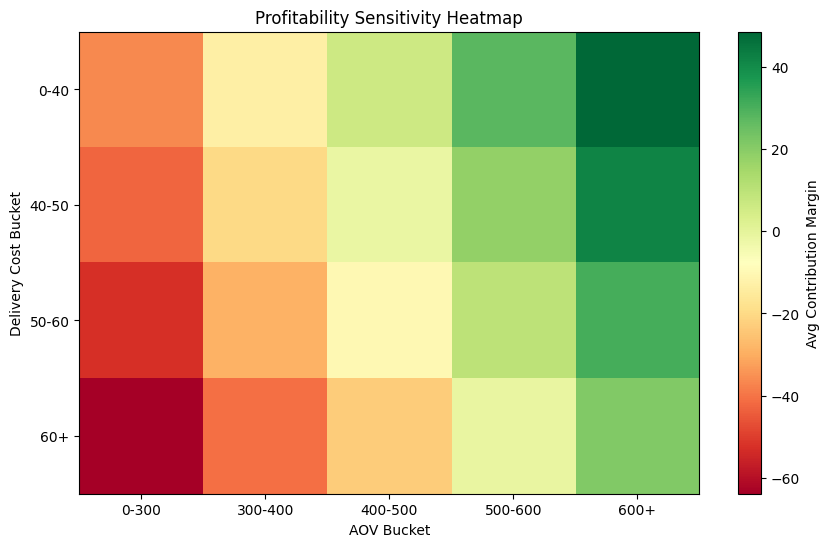

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.imshow(heatmap_data, cmap="RdYlGn", aspect="auto")

plt.colorbar(label="Avg Contribution Margin")

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xlabel("AOV Bucket")
plt.ylabel("Delivery Cost Bucket")

plt.title("Profitability Sensitivity Heatmap")

plt.show()

In [6]:
kpi_data = {
    "Metric": [
        "Avg Order Value",
        "Avg Contribution Margin",
        "Avg Rider Cost"
    ],

    "Value": [
        round(df["order_value"].mean(),2),
        round(df["contribution_margin"].mean(),2),
        round(df["rider_cost"].mean(),2)
    ]
}

kpi_df = pd.DataFrame(kpi_data)

fig = px.bar(
    kpi_df,
    x="Metric",
    y="Value",
    color="Metric",
    title="Executive KPI Snapshot"
)

fig.show()